# Notebook 04: Predictive Modeling

### Import Libraries

In [39]:
import pandas as pd
import numpy as np

from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge

from xgboost import XGBRegressor

import matplotlib.pyplot as plt

import joblib

### Load Data

In [4]:
df = pd.read_csv('../data/processed/merged_df.csv')

## Identify Feature and Target Variables

In [5]:
features = ['PTS', 'REB', 'AST', 'STL', 'BLK', 'MIN', 'GP',
            'FG_PCT', 'FG3_PCT', 'FT_PCT', 'PLUS_MINUS',
            'W_PCT', 'TEAM_W', 'PTS_RANK', 'AST_RANK', 
            'REB_RANK', 'PLUS_MINUS_RANK', 'W_RANK']

target = 'MVP_SHARE'

## Split Data into Train and Test Sets

In [6]:
# train on 2000-2023, test on 2024-2026
train = df[df['SEASON'] <= 2023]
test = df[df['SEASON'] >= 2024]

# split data
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

# look at dimensions of the split
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Training non-zero shares: {(y_train > 0).sum()}")
print(f"Test non-zero shares: {(y_test > 0).sum()}")

Training samples: 4837
Test samples: 620
Training non-zero shares: 334
Test non-zero shares: 29


## Model 1: Ridge Regression

In [8]:
# scale features before fitting model
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# train ridge regression model
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)

In [14]:
# evaluate model using R-squared and RMSE
print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.4f}")
print(f"R2: {r2_score(y_test, y_pred):.4f}")

RMSE: 0.0756
R2: 0.2995


In [15]:
# observe the predicted top 5 MVP finishers for each season against the actual results
test_results = test[['SEASON', 'PLAYER_NAME', 'MVP_SHARE']].copy()
test_results['PREDICTED_SHARE'] = y_pred

for season in sorted(test_results['SEASON'].unique()):
    season_df = test_results[test_results['SEASON'] == season]
    print(f"\n--- {season} Top 5 Predicted vs Actual ---")
    print(season_df.nlargest(5, 'PREDICTED_SHARE')[['PLAYER_NAME', 'PREDICTED_SHARE', 'MVP_SHARE']].to_string())


--- 2024 Top 5 Predicted vs Actual ---
                  PLAYER_NAME  PREDICTED_SHARE  MVP_SHARE
4977              Luka Dončić         0.300365      0.572
4994             Nikola Jokić         0.299104      0.935
5021  Shai Gilgeous-Alexander         0.262408      0.646
4911    Giannis Antetokounmpo         0.250503      0.194
4930            Jalen Brunson         0.219253      0.143

--- 2025 Top 5 Predicted vs Actual ---
                  PLAYER_NAME  PREDICTED_SHARE  MVP_SHARE
5221  Shai Gilgeous-Alexander         0.339911      0.913
5197             Nikola Jokić         0.311695      0.787
5114    Giannis Antetokounmpo         0.230674      0.470
5143             Jayson Tatum         0.188056      0.311
5178              Luka Dončić         0.168350      0.000

--- 2026 Top 5 Predicted vs Actual ---
                  PLAYER_NAME  PREDICTED_SHARE  MVP_SHARE
5433  Shai Gilgeous-Alexander         0.274237      0.939
5401             Nikola Jokić         0.271153      0.634
5380      

## Model 2: Random Forest Regressor

In [24]:
# initialize rf model
rf = RandomForestRegressor()

# create param dict for random search
param_dict = {
    'n_estimators': range(50, 300),       # number of trees
    'max_depth': range(2, 20),            # tree depth
    'min_samples_split': range(2, 10),    # min samples to split
    'min_samples_leaf': range(1, 10),     # min samples per leaf
    'max_features': ['sqrt', 'log2', None]  # feature selection strategy
}

# create a cv strategy that protects order of the data
tscv = TimeSeriesSplit(n_splits=5)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dict,
    n_iter=50,  # number of random combinations to try
    scoring='neg_root_mean_squared_error',  # metric to optimize
    cv=tscv,    # cross-validation strategy
    random_state=42,   # reproducibility
    n_jobs=-1,   # use all CPU cores
    verbose=2
)

# run the search
random_search.fit(X_train, y_train)

# display best parameters and score
print("Best Parameters:", random_search.best_params_)
print("Best Cross-Validation Accuracy:", random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'n_estimators': 297, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 16}
Best Cross-Validation Accuracy: -0.05724224921629147


In [25]:
# train rf model and predict vals for test set
best_rf = random_search.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)

In [26]:
# evaluate model using R-squared and RMSE
print(f"Tuned RF RMSE: {root_mean_squared_error(y_test, y_pred_rf_tuned):.4f}")
print(f"Tuned RF R2: {r2_score(y_test, y_pred_rf_tuned):.4f}")

Tuned RF RMSE: 0.0306
Tuned RF R2: 0.8848


In [27]:
# observe the predicted top 5 MVP finishers for each season against the actual results
test_results = test[['SEASON', 'PLAYER_NAME', 'MVP_SHARE']].copy()
test_results['PREDICTED_SHARE'] = y_pred_rf_tuned

for season in sorted(test_results['SEASON'].unique()):
    season_df = test_results[test_results['SEASON'] == season]
    print(f"\n--- {season} Top 5 Predicted vs Actual ---")
    print(season_df.nlargest(5, 'PREDICTED_SHARE')[['PLAYER_NAME', 'PREDICTED_SHARE', 'MVP_SHARE']].to_string())


--- 2024 Top 5 Predicted vs Actual ---
                  PLAYER_NAME  PREDICTED_SHARE  MVP_SHARE
5021  Shai Gilgeous-Alexander         0.667139      0.646
4994             Nikola Jokić         0.656637      0.935
4977              Luka Dončić         0.528978      0.572
4911    Giannis Antetokounmpo         0.414829      0.194
4941             Jayson Tatum         0.287665      0.087

--- 2025 Top 5 Predicted vs Actual ---
                  PLAYER_NAME  PREDICTED_SHARE  MVP_SHARE
5221  Shai Gilgeous-Alexander         0.784402      0.913
5197             Nikola Jokić         0.648941      0.787
5143             Jayson Tatum         0.429406      0.311
5114    Giannis Antetokounmpo         0.328743      0.470
5057          Anthony Edwards         0.183105      0.012

--- 2026 Top 5 Predicted vs Actual ---
                  PLAYER_NAME  PREDICTED_SHARE  MVP_SHARE
5433  Shai Gilgeous-Alexander         0.753300      0.939
5401             Nikola Jokić         0.548672      0.634
5380      

## Model 3: XGBoosted Regressor

In [28]:
# train xgb model
xgb = XGBRegressor()

# create param dict for random search
xgb_params = {
    'n_estimators': range(50, 300),
    'max_depth': range(2, 10),
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': range(1, 10)
}

# create a cv strategy that protects order of the data
tscv = TimeSeriesSplit(n_splits=5)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=50,  # number of random combinations to try
    scoring='neg_root_mean_squared_error',  # metric to optimize
    cv=tscv,    # cross-validation strategy
    random_state=42,   # reproducibility
    n_jobs=-1,   # use all CPU cores
    verbose=2
)

# run the search
random_search.fit(X_train, y_train)

# display best parameters and score
print("Best Parameters:", random_search.best_params_)
print("Best Cross-Validation Accuracy:", random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'subsample': 0.6, 'n_estimators': 147, 'min_child_weight': 7, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
Best Cross-Validation Accuracy: -0.05627949552613785


In [32]:
# train xgb model and predict vals for test set
best_xgb = random_search.best_estimator_
y_pred_xgb_tuned = best_xgb.predict(X_test)
y_pred_xgb_tuned = np.clip(y_pred_xgb_tuned, 0, 1)

In [33]:
# evaluate model using R-squared and RMSE
print(f"Tuned RF RMSE: {root_mean_squared_error(y_test, y_pred_xgb_tuned):.4f}")
print(f"Tuned RF R2: {r2_score(y_test, y_pred_xgb_tuned):.4f}")

Tuned RF RMSE: 0.0341
Tuned RF R2: 0.8573


In [34]:
# observe the predicted top 5 MVP finishers for each season against the actual results
test_results = test[['SEASON', 'PLAYER_NAME', 'MVP_SHARE']].copy()
test_results['PREDICTED_SHARE'] = y_pred_xgb_tuned

for season in sorted(test_results['SEASON'].unique()):
    season_df = test_results[test_results['SEASON'] == season]
    print(f"\n--- {season} Top 5 Predicted vs Actual ---")
    print(season_df.nlargest(5, 'PREDICTED_SHARE')[['PLAYER_NAME', 'PREDICTED_SHARE', 'MVP_SHARE']].to_string())


--- 2024 Top 5 Predicted vs Actual ---
                  PLAYER_NAME  PREDICTED_SHARE  MVP_SHARE
4994             Nikola Jokić         0.840743      0.935
5021  Shai Gilgeous-Alexander         0.770285      0.646
4977              Luka Dončić         0.752569      0.572
4911    Giannis Antetokounmpo         0.468816      0.194
4930            Jalen Brunson         0.314035      0.143

--- 2025 Top 5 Predicted vs Actual ---
                  PLAYER_NAME  PREDICTED_SHARE  MVP_SHARE
5221  Shai Gilgeous-Alexander         1.000000      0.913
5197             Nikola Jokić         0.873783      0.787
5143             Jayson Tatum         0.552613      0.311
5114    Giannis Antetokounmpo         0.360761      0.470
5057          Anthony Edwards         0.154034      0.012

--- 2026 Top 5 Predicted vs Actual ---
                  PLAYER_NAME  PREDICTED_SHARE  MVP_SHARE
5433  Shai Gilgeous-Alexander         0.961153      0.939
5380              Luka Dončić         0.666552      0.250
5401      

Based on the results from the models above, the model chosen to be the candidate for MVP Prediction is the XGBoost Regressor. It is certainly true that the Random Forest Regressor could also very easily been chosen, but the ability for the XGB model to correctly predict all 3 winners in the test set while also producing comparable R-squared and RMSE metrics gives me the confidence I need to chose it as the candidate model. After all, this main functionality of this model is to be able to correcty predict the MVP WINNER, and the XGB model does that consistently

## Identify Feature Importances in Candidate Model

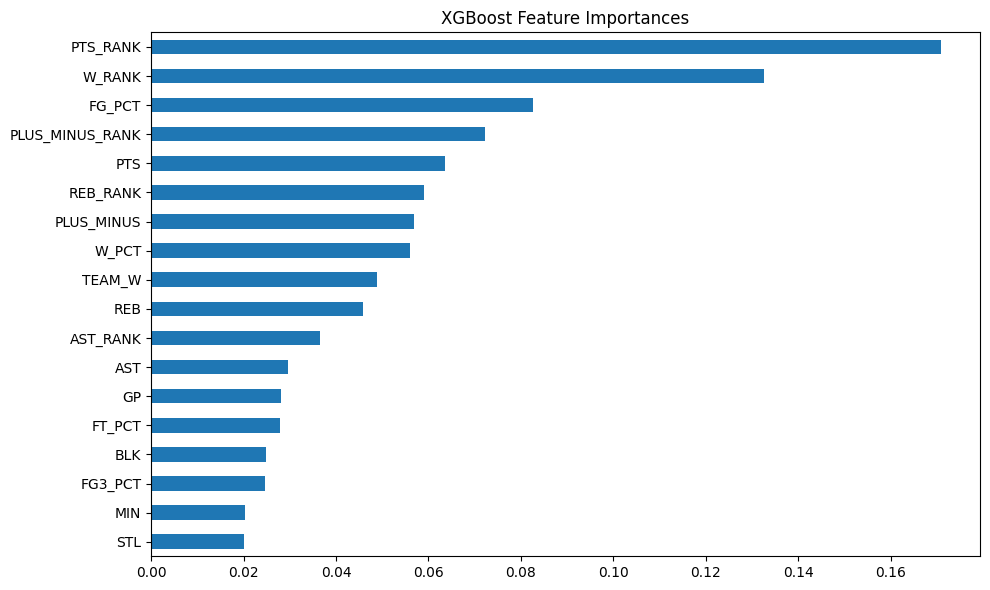

In [38]:
importances = pd.Series(best_xgb.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', figsize=(10, 6))
plt.title('XGBoost Feature Importances')
plt.tight_layout()
plt.show()

## Save Candidate Model

In [40]:
joblib.dump(best_xgb, '../models/xgb_mvp_predictor.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

['../models/scaler.pkl']